# ⚽ WC2026 — Upcoming Match Predictions Dashboard

Builds the Elo + XGBoost pipeline **once**, predicts every upcoming World Cup 2026
fixture (pulled live from [openfootball](https://github.com/openfootball/worldcup.json)),
and renders a visually rich results table you can drop straight into a video.

For each game the model returns the **predicted winner**, a **scoreline**, a
**confidence** number, and the full home/draw/away win probabilities.

Works at **every stage of the tournament** — during the group stage it predicts the
remaining group games; once the knockouts begin it predicts the Round of 32 → Final
and projects the **most likely bracket** all the way to the champion.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pathlib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from predictor import (
    load_results, EloRatingSystem, build_features, train_model,
    upcoming_fixtures, predict_match, COLORS,
)

# Build the pipeline ONCE: data -> Elo -> features -> model.
# (load_results pulls the latest played WC2026 results from openfootball too.)
df      = load_results()
elo     = EloRatingSystem().fit(df)
feat_df = build_features(df, elo)
model   = train_model(feat_df)

📂  Loading cached match history …
    Dropped 60 rows with missing scores.
    32,299 historical matches loaded (1990–present).
    🏟️  Merged 103 played WC2026 matches from openfootball.
⚙️   Engineering features …
    Feature matrix: (32389, 17)
🤖  Training XGBoost classifier …
    CV accuracy: 0.579 ± 0.003

    Training set report:
              precision    recall  f1-score   support

    Away win       0.56      0.60      0.58      9074
        Draw       0.60      0.04      0.07      7618
    Home win       0.62      0.87      0.72     15697

    accuracy                           0.60     32389
   macro avg       0.59      0.50      0.46     32389
weighted avg       0.60      0.60      0.53     32389



## 🔮 Predict every upcoming fixture

Loop over the live schedule once — no retraining per game.

In [2]:
fixtures = upcoming_fixtures()

# Short, stage-agnostic label so the dashboard works in the group stage AND the
# knockout rounds (where `group` is None and `round` is "Round of 32" etc.).
ROUND_ABBR = {
    "Round of 32": "R32", "Round of 16": "R16", "Quarter-final": "QF",
    "Semi-final": "SF", "Match for third place": "3rd", "Final": "Final",
}

def stage_label(fx):
    if pd.notna(fx.get("group")) and fx.get("group"):
        return str(fx["group"]).replace("Group ", "")          # "Group G" -> "G"
    rnd = fx.get("round")
    return ROUND_ABBR.get(rnd, rnd if pd.notna(rnd) else "KO")  # knockout round

rows = []
for _, fx in fixtures.iterrows():
    p = predict_match(fx.home_team, fx.away_team, elo, model, feat_df,
                      neutral=bool(fx.neutral), is_wc=True)
    rows.append({
        "Date":     fx.date.date(),
        "Stage":    stage_label(fx),
        "Home":     p["home"],
        "Away":     p["away"],
        "Pick":     p["winner"],
        "Score":    f"{p['score_home']}–{p['score_away']}",
        "Conf":     p["confidence"],
        "Home win": p["p_home"],
        "Draw":     p["p_draw"],
        "Away win": p["p_away"],
    })

pred = pd.DataFrame(rows)
stages = ", ".join(pred["Stage"].unique()) if not pred.empty else "—"
print(f"Predicted {len(pred)} upcoming fixtures · stages: {stages}")
pred.head()

Predicted 1 upcoming fixtures · stages: Final


,Date,Stage,Home,Away,Pick,Score,Conf,Home win,Draw,Away win
0,2026-07-19,Final,Spain,Argentina,Spain,2–1,0.392,0.392,0.318,0.291


## 📊 Visual prediction table

Win-probability bars (blue = home, grey = draw, red = away), a confidence
heat-map, and the model's pick for every fixture.

In [3]:
view = pred.copy()
view["Pick"] = view.apply(
    lambda r: f"\U0001f3c5 {r['Pick']}" if r["Pick"] != "Draw" else "\U0001f91d Draw",
    axis=1,
)

styled = (
    view.style
        .format({"Conf": "{:.0%}", "Home win": "{:.0%}",
                 "Draw": "{:.0%}", "Away win": "{:.0%}"})
        .bar(subset=["Home win"], color="#2563EB99", vmin=0, vmax=1)
        .bar(subset=["Draw"],     color="#64748B99", vmin=0, vmax=1)
        .bar(subset=["Away win"], color="#DC262699", vmin=0, vmax=1)
        .background_gradient(subset=["Conf"], cmap="YlGn", vmin=0.33, vmax=1)
        .set_properties(**{"text-align": "center", "font-size": "12px"})
        .set_table_styles([
            {"selector": "th",
             "props": [("background-color", "#0F172A"), ("color", "#F8FAFC"),
                       ("text-align", "center"), ("padding", "6px 10px")]},
            {"selector": "caption",
             "props": [("caption-side", "top"), ("font-size", "18px"),
                       ("font-weight", "bold"), ("color", "#F59E0B"),
                       ("padding-bottom", "8px")]},
        ]) 
        .set_caption("WC2026 — AI Match Predictions")
        .hide(axis="index")
)
styled

Date,Stage,Home,Away,Pick,Score,Conf,Home win,Draw,Away win
2026-07-19,Final,Spain,Argentina,🏅 Spain,2–1,39%,39%,32%,29%


## 🎬 YouTube-style table (dark-theme PNG)

Same data rendered on the project's dark thumbnail theme and saved to `visuals/`.

Saved → visuals/predictions_table.png


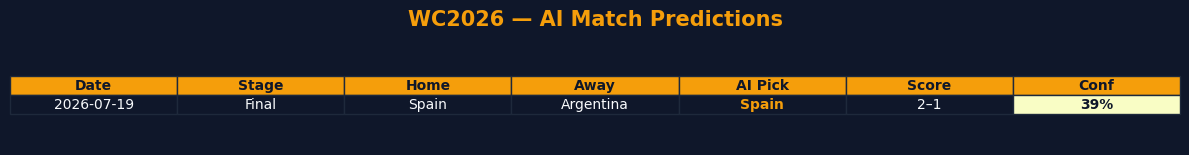

In [4]:
def render_dark_table(pred, n=None, save_path="visuals/predictions_table.png"):
    """Render predictions as a dark, video-ready table PNG (n=None for all rows)."""
    data = pred if n is None else pred.head(n)
    cmap = plt.get_cmap("YlGn")

    cell_text = [[
        str(r["Date"]), r["Stage"],
        r["Home"], r["Away"], r["Pick"], r["Score"], f"{r['Conf']*100:.0f}%",
    ] for _, r in data.iterrows()]

    fig, ax = plt.subplots(figsize=(12, 0.45 * len(cell_text) + 1.2),
                           facecolor=COLORS["bg"])
    ax.axis("off")
    tbl = ax.table(
        cellText=cell_text,
        colLabels=["Date", "Stage", "Home", "Away", "AI Pick", "Score", "Conf"],
        cellLoc="center", loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.45)

    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor("#1E293B")
        if r == 0:  # header row
            cell.set_facecolor(COLORS["accent"])
            cell.set_text_props(color=COLORS["bg"], fontweight="bold")
            continue
        conf = data.iloc[r - 1]["Conf"]
        cell.set_facecolor(COLORS["bg"])
        cell.set_text_props(color=COLORS["text"])
        if c == 6:  # confidence heat-map
            cell.set_facecolor(cmap((conf - 0.33) / 0.67))
            cell.set_text_props(color="#0F172A", fontweight="bold")
        elif c == 4:  # AI pick accent
            cell.set_text_props(color=COLORS["accent"], fontweight="bold")

    ax.set_title("WC2026 — AI Match Predictions", color=COLORS["accent"],
                 fontsize=15, fontweight="bold", pad=14)
    plt.tight_layout()
    pathlib.Path(save_path).parent.mkdir(exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=COLORS["bg"])
    print(f"Saved → {save_path}")
    plt.show()


# Next 12 fixtures (set n=None to render the whole slate)
render_dark_table(pred, n=12)

## 💾 Export

Save the predictions as CSV + standalone HTML for re-use.

In [5]:
out_dir = pathlib.Path("visuals")
out_dir.mkdir(exist_ok=True)

pred.to_csv(out_dir / "upcoming_predictions.csv", index=False)
styled.to_html(out_dir / "upcoming_predictions.html")
print("Saved → visuals/upcoming_predictions.csv and .html")

Saved → visuals/upcoming_predictions.csv and .html


In [6]:
# ── Reconstruct the model's view of the world at each point in the group stage ──
# For every "as-of" date we retrain the WHOLE pipeline (Elo → features → XGBoost)
# on ONLY the matches played *before* that date, then record:
#   (a) Monte-Carlo title odds for all 48 teams, and
#   (b) the win-probability + predicted scoreline for every still-upcoming fixture.
# Comparing snapshots shows how the model's opinion moves as real results arrive.
#
# This is the heaviest cell in the notebook, so it is both PARALLELISED (one process
# per as-of date, via joblib) and CACHED to disk: a snapshot depends only on the
# matches played *before* its date, and history is immutable, so past snapshots are
# reused across runs and only genuinely-new/changed ones are recomputed. Set
# FORCE_REBUILD = True to ignore the cache.
import hashlib
from collections import defaultdict
from joblib import Parallel, delayed
from predictor import FEATURE_COLS, WC2026_MATCHES
import xgboost as xgb

FULL     = df          # full history, including the live WC2026 results merged above
UPCOMING = fixtures    # fixtures still to be played (live from openfootball)
WC_TEAMS = sorted({t for mm in WC2026_MATCHES for t in (mm[0], mm[1])})

FORCE_REBUILD = False                              # True ⇒ bypass the disk cache
CACHE_DIR     = pathlib.Path("data/snapshot_cache")
# Columns that define a snapshot's input — the hash over these self-invalidates the
# cache if any historical result is ever revised upstream.
HASH_COLS = ["date", "home_team", "away_team", "home_score", "away_score", "tournament"]


def _train_fast(feat_df, n_jobs=1):
    """Same XGBoost config as train_model() but skips CV/report for speed.

    Pinned to a single thread by default so results are fully reproducible (XGBoost
    can vary slightly with thread count) and so N parallel snapshots don't each grab
    every core; the single-threaded Monte-Carlo is the real bottleneck anyway.
    """
    X = feat_df[FEATURE_COLS].fillna(0)
    y = feat_df["outcome"]
    m = xgb.XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, use_label_encoder=False,
        eval_metric="mlogloss", random_state=42, n_jobs=n_jobs,
    )
    m.fit(X, y)
    return m


def snapshot(as_of):
    """Rebuild Elo + features + model using only matches before `as_of`."""
    hist = FULL[FULL["date"] < pd.Timestamp(as_of)].copy()
    elo  = EloRatingSystem().fit(hist)
    feat = build_features(hist, elo)
    return elo, _train_fast(feat), feat


def championship_odds(elo, model, feat, n_sims=2000, seed=42):
    """Monte-Carlo title odds for all 48 teams (match probs memoised for speed)."""
    cache = {}
    def winp(h, a):
        if (h, a) not in cache:
            p = predict_match(h, a, elo, model, feat, neutral=True, is_wc=True)
            cache[(h, a)] = (p["p_home"], p["p_draw"], p["p_away"])
        return cache[(h, a)]
    rng, wins = np.random.default_rng(seed), defaultdict(int)
    for _ in range(n_sims):
        rem = WC_TEAMS[:]
        while len(rem) > 1:
            rng.shuffle(rem)
            nxt = []
            for i in range(0, len(rem) - 1, 2):
                h, a = rem[i], rem[i + 1]
                ph, pdraw, pa = winp(h, a)
                r = rng.random()
                nxt.append(h if r < ph else
                           (a if r > ph + pdraw else (h if rng.random() > 0.5 else a)))
            if len(rem) % 2:
                nxt.append(rem[-1])
            rem = nxt
        wins[rem[0]] += 1
    return {t: wins[t] / n_sims * 100 for t in WC_TEAMS}


# ── Disk cache keyed by (as-of date + content hash of the pre-as-of data slice) ──
def _slice_key(ao):
    hist = FULL[FULL["date"] < pd.Timestamp(ao)]
    digest = hashlib.sha1(
        pd.util.hash_pandas_object(hist[HASH_COLS], index=False).values.tobytes()
    ).hexdigest()[:12]
    return f"{pd.Timestamp(ao):%Y-%m-%d}_{digest}"


def _cache_paths(ao):
    k = _slice_key(ao)
    return CACHE_DIR / f"champ_{k}.pkl", CACHE_DIR / f"fixpred_{k}.pkl"


def _load_cached(ao, need_matchups):
    """Return (champ_df, fixpred_df) if a valid cache covers `need_matchups`, else None."""
    if FORCE_REBUILD:
        return None
    cp, fp = _cache_paths(ao)
    if not (cp.exists() and fp.exists()):
        return None
    champ, fixpred = pd.read_pickle(cp), pd.read_pickle(fp)
    have = set(map(tuple, fixpred[["home", "away"]].to_numpy()))
    if not need_matchups <= have:      # a currently-upcoming fixture isn't cached ⇒ recompute
        return None
    return champ, fixpred


def _save_cached(ao, champ, fixpred):
    cp, fp = _cache_paths(ao)
    champ.to_pickle(cp)
    fixpred.to_pickle(fp)


def _compute_snapshot(ao):
    """Train the snapshot ONCE, then return its cacheable parts:
    title odds (per team) and win-prob/scoreline (per upcoming matchup)."""
    elo_s, model_s, feat_s = snapshot(ao)
    champ = pd.DataFrame(
        [{"team": t, "title_pct": pct}
         for t, pct in championship_odds(elo_s, model_s, feat_s).items()])
    rows, seen = [], set()
    for fx in UPCOMING.itertuples(index=False):
        key = (fx.home_team, fx.away_team)
        if key in seen:                # one prediction per distinct matchup
            continue
        seen.add(key)
        p = predict_match(fx.home_team, fx.away_team, elo_s, model_s, feat_s,
                          neutral=bool(fx.neutral), is_wc=True)
        rows.append({
            "home": fx.home_team, "away": fx.away_team,
            "p_home": p["p_home"], "p_draw": p["p_draw"], "p_away": p["p_away"],
            "xg_home": p["xg_home"], "xg_away": p["xg_away"],
            "score": f"{p['score_home']}–{p['score_away']}",
            "winner": p["winner"], "conf": p["confidence"],
        })
    return champ, pd.DataFrame(rows)


# Snapshot dates are derived from the live data so the timeline always spans the
# group stage up to *today* — no hand-edited dates. We take the tournament opener
# (0 played) plus the morning-after of each WC2026 match-day, then evenly sample
# up to MAX_SNAPS points (retraining the whole pipeline per date is expensive).
MAX_SNAPS = 7
opener = pd.Timestamp("2026-06-11")
wc_played = FULL[(FULL["tournament"] == "FIFA World Cup") & (FULL["date"] >= opener)]
play_dates = sorted(pd.Series(wc_played["date"]).dt.normalize().unique())
# "as of the morning after" a match-day ⇒ that day's results count as played
cand = sorted({opener, *[pd.Timestamp(d) + pd.Timedelta(days=1) for d in play_dates]})
if len(cand) > MAX_SNAPS:
    idx = np.unique(np.linspace(0, len(cand) - 1, MAX_SNAPS).round().astype(int))
    cand = [cand[i] for i in idx]
AS_OF = [d.strftime("%Y-%m-%d") for d in cand]

base = (FULL["date"] < opener).sum()   # rows before the tournament opener
REQ  = set(map(tuple, UPCOMING[["home_team", "away_team"]].to_numpy()))  # matchups to cover

# Resolve cache hits up front, then (re)compute only the misses IN PARALLEL.
CACHE_DIR.mkdir(parents=True, exist_ok=True)
cached = {ao: _load_cached(ao, REQ) for ao in AS_OF}
todo   = [ao for ao in AS_OF if cached[ao] is None]
print(f"⏳  Reconstructing prediction history · {len(AS_OF) - len(todo)} cached, "
      f"{len(todo)} to (re)compute in parallel…")
computed = dict(zip(todo, Parallel(n_jobs=-1)(delayed(_compute_snapshot)(ao) for ao in todo)))
for ao in todo:                        # persist new/changed snapshots for next run
    _save_cached(ao, *computed[ao])

# Reassemble in AS_OF order so row order (and downstream output) stays deterministic.
champ_rows, fix_rows = [], []
for ao in AS_OF:
    champ, fixpred = cached[ao] if cached[ao] is not None else computed[ao]
    ts       = pd.Timestamp(ao)
    n_played = int((FULL["date"] < ts).sum() - base)
    for r in champ.itertuples(index=False):
        champ_rows.append({"as_of": ts, "n_played": n_played,
                           "team": r.team, "title_pct": r.title_pct})
    pred_by = {(r.home, r.away): r for r in fixpred.itertuples(index=False)}
    for fx in UPCOMING.itertuples(index=False):
        p = pred_by[(fx.home_team, fx.away_team)]
        fix_rows.append({
            "as_of": ts, "n_played": n_played,
            "match": f"{fx.home_team} v {fx.away_team}", "date": fx.date.date(),
            "group": fx.group, "home": fx.home_team, "away": fx.away_team,
            "p_home": p.p_home, "p_draw": p.p_draw, "p_away": p.p_away,
            "xg_home": p.xg_home, "xg_away": p.xg_away,
            "score": p.score, "winner": p.winner, "conf": p.conf,
        })
    print(f"    as of {ao}  ·  {n_played:>2} WC2026 matches played"
          f"{'  (cached)' if cached[ao] is not None else ''}")

champ_hist = pd.DataFrame(champ_rows)
fix_hist   = pd.DataFrame(fix_rows)

out_dir = pathlib.Path("visuals"); out_dir.mkdir(exist_ok=True)
champ_hist.to_csv(out_dir / "title_odds_history.csv", index=False)
fix_hist.to_csv(out_dir / "fixture_prediction_history.csv", index=False)
print(f"\n✅  {len(AS_OF)} snapshots · {champ_hist.shape[0]} title rows · "
      f"{fix_hist.shape[0]} fixture rows")
print("    Saved → visuals/title_odds_history.csv & fixture_prediction_history.csv")

⏳  Reconstructing prediction history · 0 cached, 7 to (re)compute in parallel…


/Users/alex/src/github.com/phreakazoid21/world-cup-2026-predictor/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/alex/src/github.com/phreakazoid21/world-cup-2026-predictor/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/alex/src/github.com/phreakazoid21/world-cup-2026-predictor/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/alex/src/github.com/phreakazoid21/world-cup-2026

⚙️   Engineering features …
⚙️   Engineering features …
⚙️   Engineering features …
⚙️   Engineering features …
⚙️   Engineering features …
⚙️   Engineering features …
⚙️   Engineering features …
    Feature matrix: (32352, 17)
    Feature matrix: (32371, 17)
    Feature matrix: (32306, 17)
    Feature matrix: (32383, 17)
    Feature matrix: (32326, 17)
    Feature matrix: (32389, 17)
    Feature matrix: (32286, 17)
    as of 2026-06-11  ·   0 WC2026 matches played
    as of 2026-06-17  ·  20 WC2026 matches played
    as of 2026-06-22  ·  40 WC2026 matches played
    as of 2026-06-27  ·  66 WC2026 matches played
    as of 2026-07-03  ·  85 WC2026 matches played
    as of 2026-07-10  ·  97 WC2026 matches played
    as of 2026-07-19  ·  103 WC2026 matches played

✅  7 snapshots · 336 title rows · 7 fixture rows
    Saved → visuals/title_odds_history.csv & fixture_prediction_history.csv


## 🏆 Title odds over time

One line per contender. A big win (or an upset) shifts a team's Elo, which ripples
through the simulation — watch the curves separate as the group stage unfolds.

Saved → visuals/title_odds_over_time.png


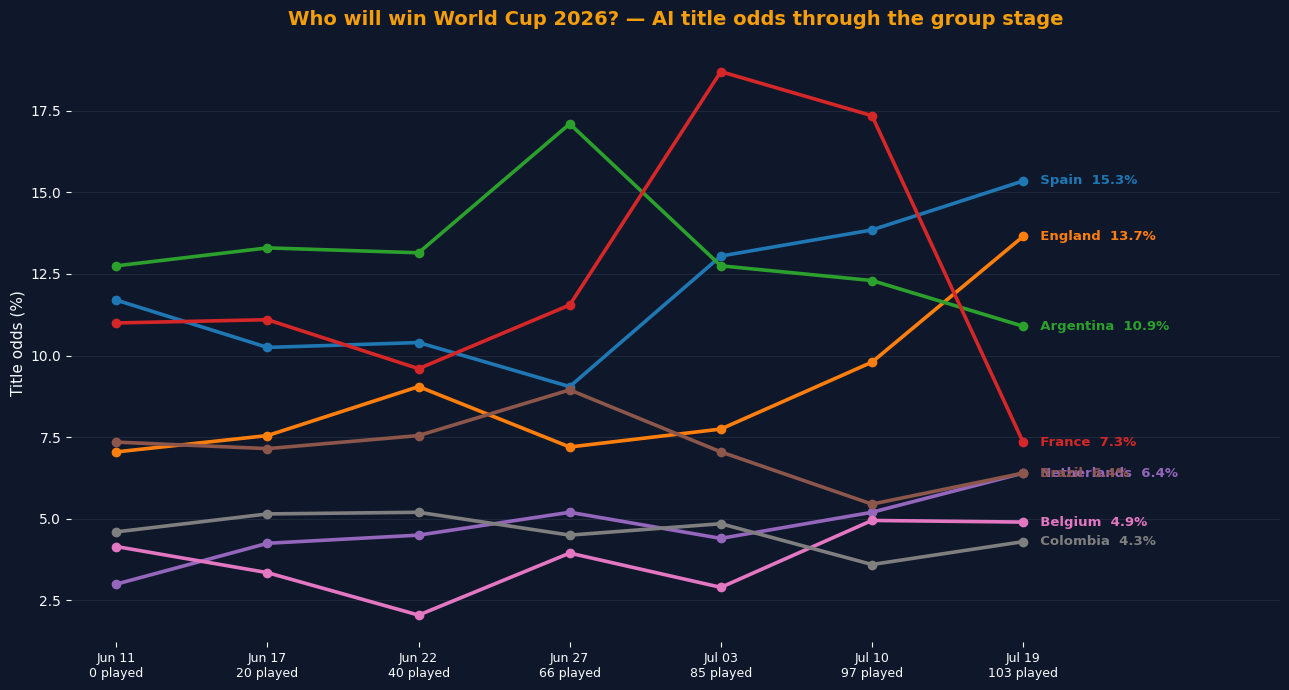


📊  Biggest title-odds movers (pre-tournament → now):
             pre_tournament   now  change
team                                     
England                 7.0  13.6     6.6
Spain                  11.7  15.4     3.6
Netherlands             3.0   6.4     3.4
Mexico                  0.8   2.6     1.8
Switzerland             2.0   2.9     1.0
Ecuador                 3.3   1.6    -1.7
Argentina              12.8  10.9    -1.8
Uruguay                 2.9   0.8    -2.1
Germany                 5.6   3.4    -2.2
France                 11.0   7.4    -3.6


In [7]:
def plot_title_odds_over_time(champ_hist, top_n=8,
                              save_path="visuals/title_odds_over_time.png"):
    """Line chart of each contender's title odds across the snapshots."""
    latest = champ_hist["as_of"].max()
    order = (champ_hist[champ_hist["as_of"] == latest]
             .sort_values("title_pct", ascending=False)["team"].head(top_n).tolist())
    piv  = champ_hist.pivot(index="as_of", columns="team", values="title_pct")[order]
    nmap = champ_hist.groupby("as_of")["n_played"].first()
    x    = list(range(len(piv.index)))

    fig, ax = plt.subplots(figsize=(13, 7), facecolor=COLORS["bg"])
    ax.set_facecolor(COLORS["bg"])
    cmap = plt.get_cmap("tab10")
    for i, team in enumerate(order):
        ax.plot(x, piv[team], marker="o", lw=2.6, ms=6, color=cmap(i % 10), label=team)
        ax.text(x[-1] + 0.05, piv[team].iloc[-1], f"  {team}  {piv[team].iloc[-1]:.1f}%",
                color=cmap(i % 10), va="center", fontsize=9.5, fontweight="bold")

    labels = [f"{d.strftime('%b %d')}\n{int(nmap[d])} played" for d in piv.index]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, color=COLORS["text"], fontsize=9)
    ax.set_xlim(-0.3, len(x) - 1 + 1.7)
    ax.set_ylabel("Title odds (%)", color=COLORS["text"], fontsize=11)
    ax.tick_params(colors=COLORS["text"])
    ax.grid(axis="y", color="#1E293B", lw=0.8)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_title("Who will win World Cup 2026? — AI title odds through the group stage",
                 color=COLORS["accent"], fontsize=14, fontweight="bold", pad=14)
    plt.tight_layout()
    pathlib.Path(save_path).parent.mkdir(exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=COLORS["bg"])
    print(f"Saved → {save_path}")
    plt.show()


plot_title_odds_over_time(champ_hist)

# Biggest title-odds movers since the pre-tournament snapshot
first, last = champ_hist["as_of"].min(), champ_hist["as_of"].max()
a = champ_hist[champ_hist["as_of"] == first].set_index("team")["title_pct"]
b = champ_hist[champ_hist["as_of"] == last ].set_index("team")["title_pct"]
movers = (pd.DataFrame({"pre_tournament": a, "now": b})
          .assign(change=lambda d: d["now"] - d["pre_tournament"])
          .sort_values("change", ascending=False))
print("\n📊  Biggest title-odds movers (pre-tournament → now):")
print(pd.concat([movers.head(5), movers.tail(5)]).round(1).to_string())

## ⚽ Upcoming-match predictions over time

For marquee fixtures still to be played, the stacked bands show the win
probability at each snapshot (blue = home win, grey = draw, red = away win) and
the **predicted scoreline** (home–away) is marked at the first and last snapshot —
so you can see a match-up tighten or open up as form data comes in.

Tracking 1 fixtures: Spain v Argentina
Saved → visuals/fixture_prob_evolution.png


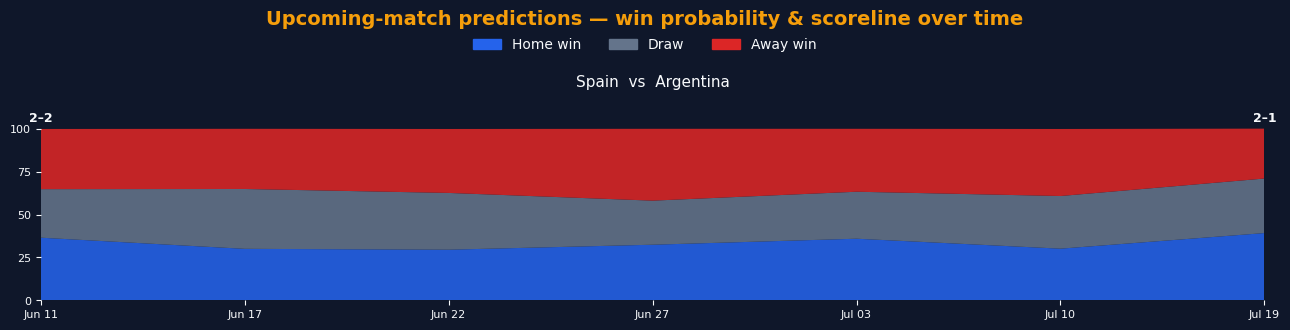

In [8]:
# Marquee fixtures to track. Start from a hand-picked list, but only keep the ones
# still upcoming — then auto-fill from the live slate so this never goes empty as
# the tournament moves into the knockouts (ranked by the two teams' title odds, so
# we surface the biggest matchups available).
WISHLIST = ["France v Senegal", "England v Croatia", "Germany v Ivory Coast",
            "Argentina v Austria", "Uruguay v Spain", "Portugal v Uzbekistan"]
N_MARQUEE = 6

avail   = set(fix_hist["match"])
MARQUEE = [m for m in WISHLIST if m in avail]

if len(MARQUEE) < N_MARQUEE and not fix_hist.empty:
    latest = champ_hist["as_of"].max()
    odds   = (champ_hist[champ_hist["as_of"] == latest]
              .set_index("team")["title_pct"].to_dict())
    uniq = fix_hist.drop_duplicates("match").copy()
    uniq["_weight"] = uniq["home"].map(odds).fillna(0) + uniq["away"].map(odds).fillna(0)
    for m in uniq.sort_values("_weight", ascending=False)["match"]:
        if m not in MARQUEE:
            MARQUEE.append(m)
        if len(MARQUEE) >= N_MARQUEE:
            break

print(f"Tracking {len(MARQUEE)} fixtures: {', '.join(MARQUEE) or '—'}")


def plot_fixture_evolution(matches, save_path="visuals/fixture_prob_evolution.png"):
    """Stacked win-probability + predicted scoreline over time for each fixture."""
    import matplotlib.patches as mpatches
    if not matches:
        print("No upcoming fixtures to plot yet.")
        return
    ncol = 2 if len(matches) > 1 else 1
    nrow = int(np.ceil(len(matches) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.1 * nrow),
                             facecolor=COLORS["bg"])
    axes = np.atleast_1d(axes).ravel()

    for ax, match in zip(axes, matches):
        g = fix_hist[fix_hist["match"] == match].sort_values("as_of")
        x = list(range(len(g)))
        ax.set_facecolor(COLORS["bg"])
        ax.stackplot(x, g["p_home"] * 100, g["p_draw"] * 100, g["p_away"] * 100,
                     colors=[COLORS["home"], COLORS["draw"], COLORS["away"]], alpha=0.88)
        # predicted scoreline (home–away) at the first & last snapshot
        for xi in (0, len(g) - 1):
            ax.text(xi, 104, g.iloc[xi]["score"], ha="center",
                    color=COLORS["text"], fontsize=9, fontweight="bold")
        home, away = g.iloc[0]["home"], g.iloc[0]["away"]
        ax.set_title(f"{home}  vs  {away}", color=COLORS["text"], fontsize=11, pad=16)
        ax.set_ylim(0, 112)
        ax.set_xlim(0, max(len(g) - 1, 1))
        ax.set_xticks(x)
        ax.set_xticklabels([d.strftime("%b %d") for d in g["as_of"]],
                           color=COLORS["text"], fontsize=7.5)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.tick_params(colors=COLORS["text"], labelsize=8)
        for s in ax.spines.values():
            s.set_visible(False)

    for ax in axes[len(matches):]:
        ax.axis("off")

    handles = [mpatches.Patch(color=COLORS["home"], label="Home win"),
               mpatches.Patch(color=COLORS["draw"], label="Draw"),
               mpatches.Patch(color=COLORS["away"], label="Away win")]
    fig.legend(handles=handles, ncol=3, loc="upper center", framealpha=0,
               facecolor=COLORS["bg"], labelcolor=COLORS["text"],
               bbox_to_anchor=(0.5, 1.0), fontsize=10)
    fig.suptitle("Upcoming-match predictions — win probability & scoreline over time",
                 color=COLORS["accent"], fontsize=14, fontweight="bold", y=1.05)
    plt.tight_layout()
    pathlib.Path(save_path).parent.mkdir(exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=COLORS["bg"])
    print(f"Saved → {save_path}")
    plt.show()


plot_fixture_evolution(MARQUEE)

## 🔎 Team focus — how one nation's outlook is shifting

`team_trend("Germany")` overlays a team's title-odds trajectory on the rest of the
field (left) and shows the win-probability + scoreline evolution for that team's
**next match** (right). Swap in any of the 48 nations.


📈  Plotting trend for USA…
Saved → visuals/team_trend_usa.png


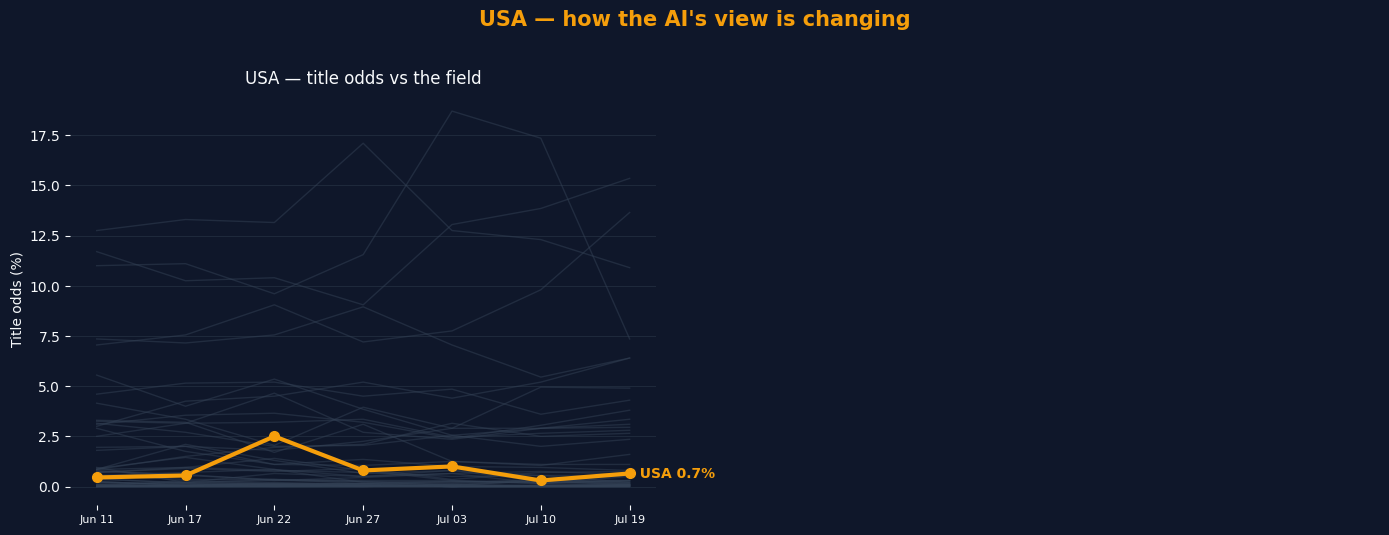


📈  Plotting trend for Belgium…
Saved → visuals/team_trend_belgium.png


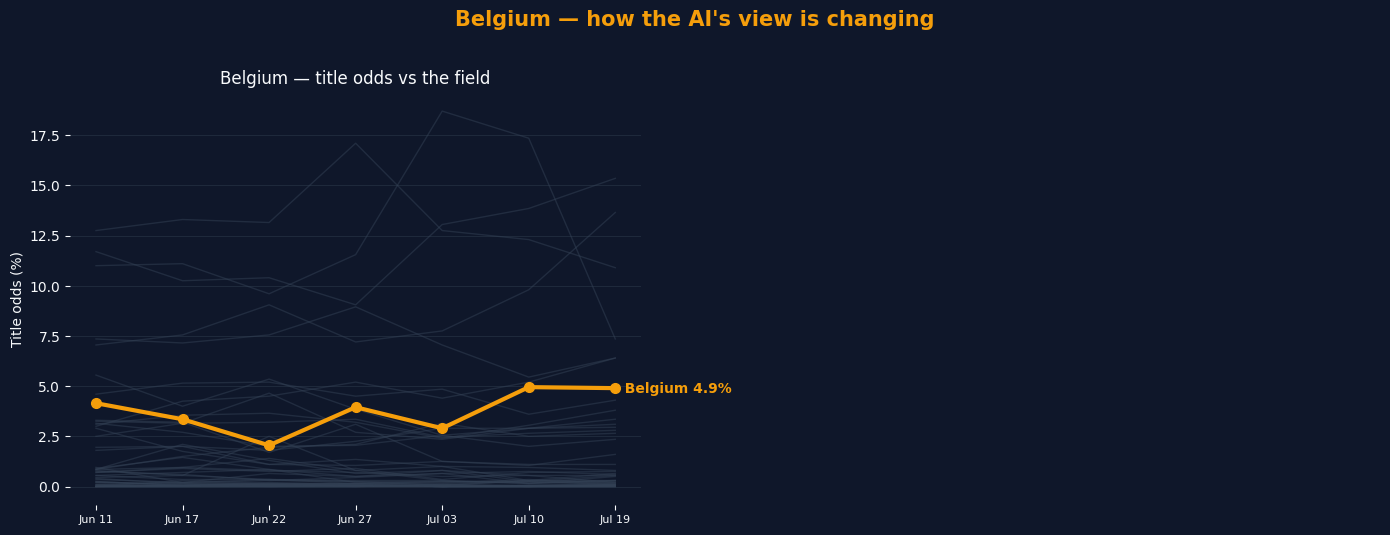


📈  Plotting trend for Argentina…
Saved → visuals/team_trend_argentina.png


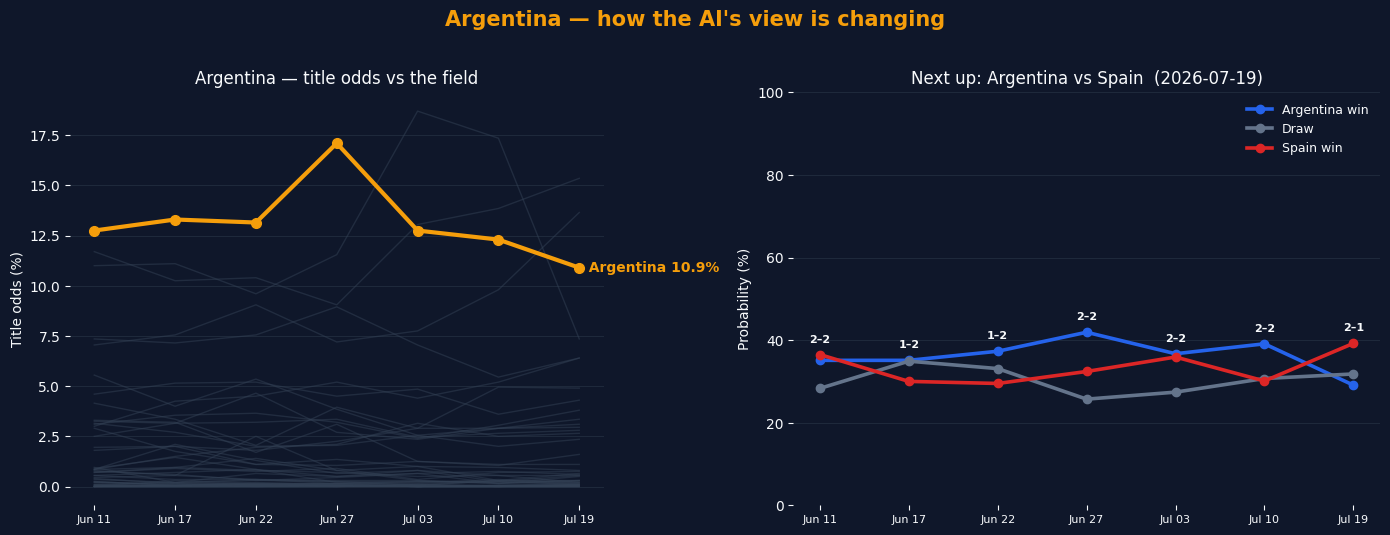


📈  Plotting trend for France…
Saved → visuals/team_trend_france.png


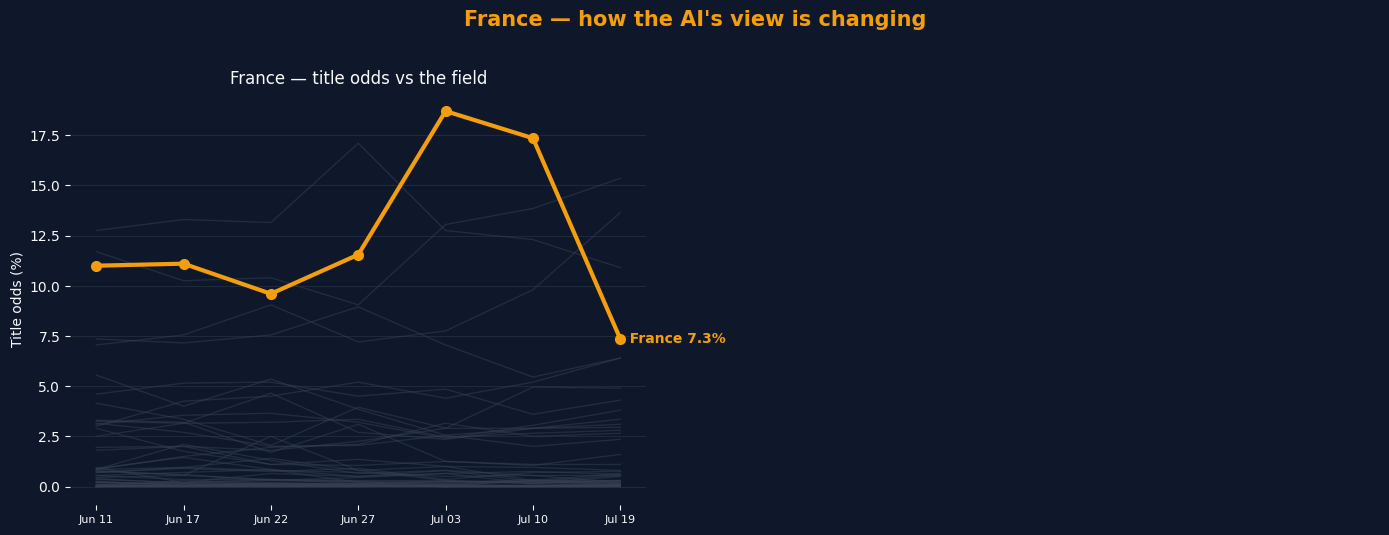


📈  Plotting trend for Norway…
Saved → visuals/team_trend_norway.png


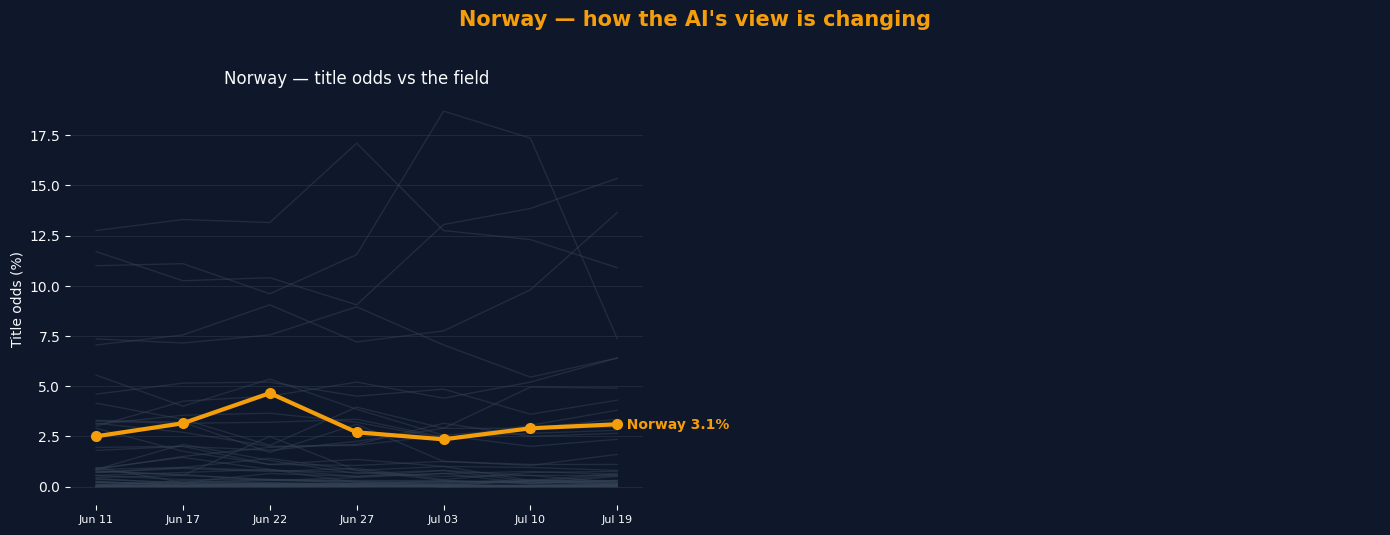


📈  Plotting trend for Egypt…
Saved → visuals/team_trend_egypt.png


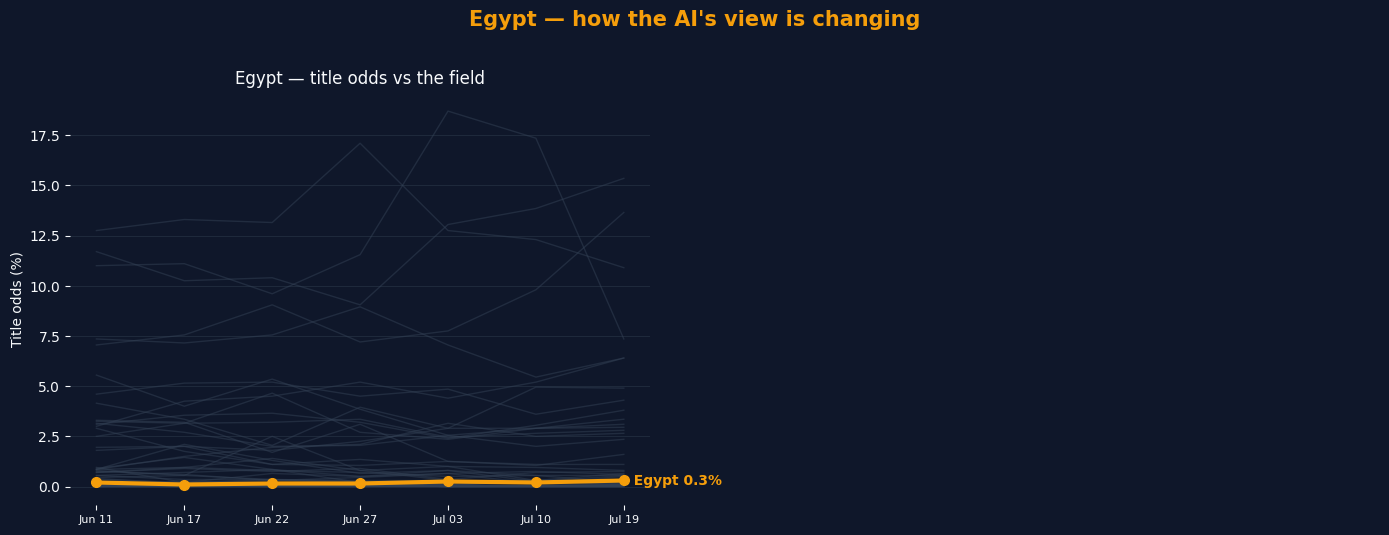


📈  Plotting trend for Portugal…
Saved → visuals/team_trend_portugal.png


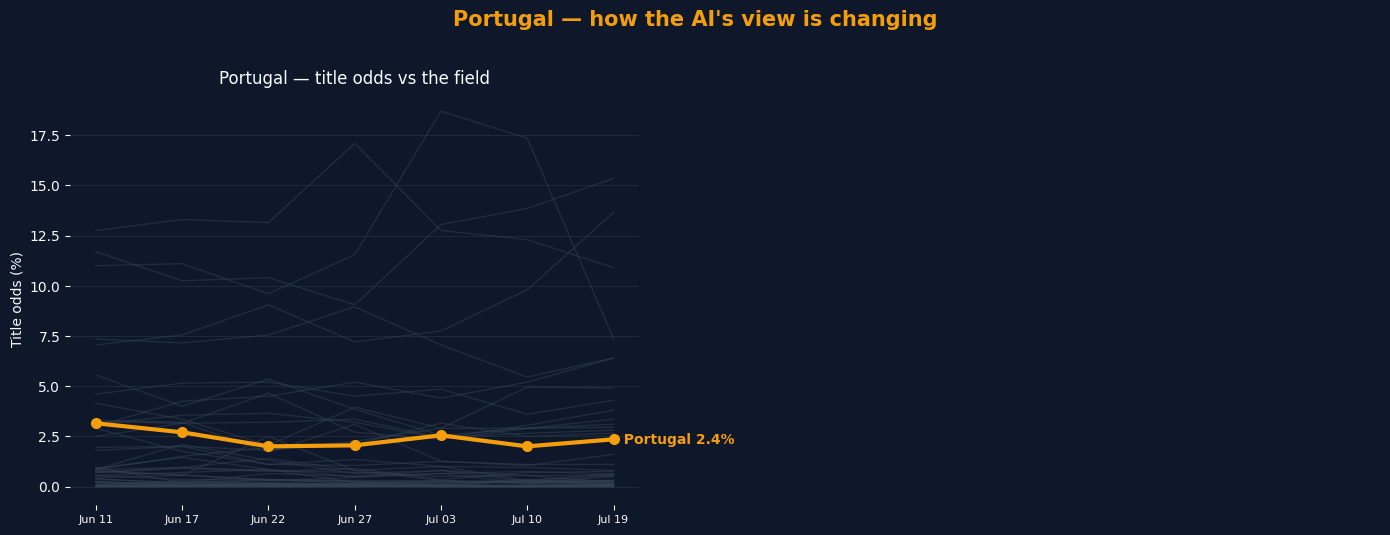


📈  Plotting trend for Switzerland…
Saved → visuals/team_trend_switzerland.png


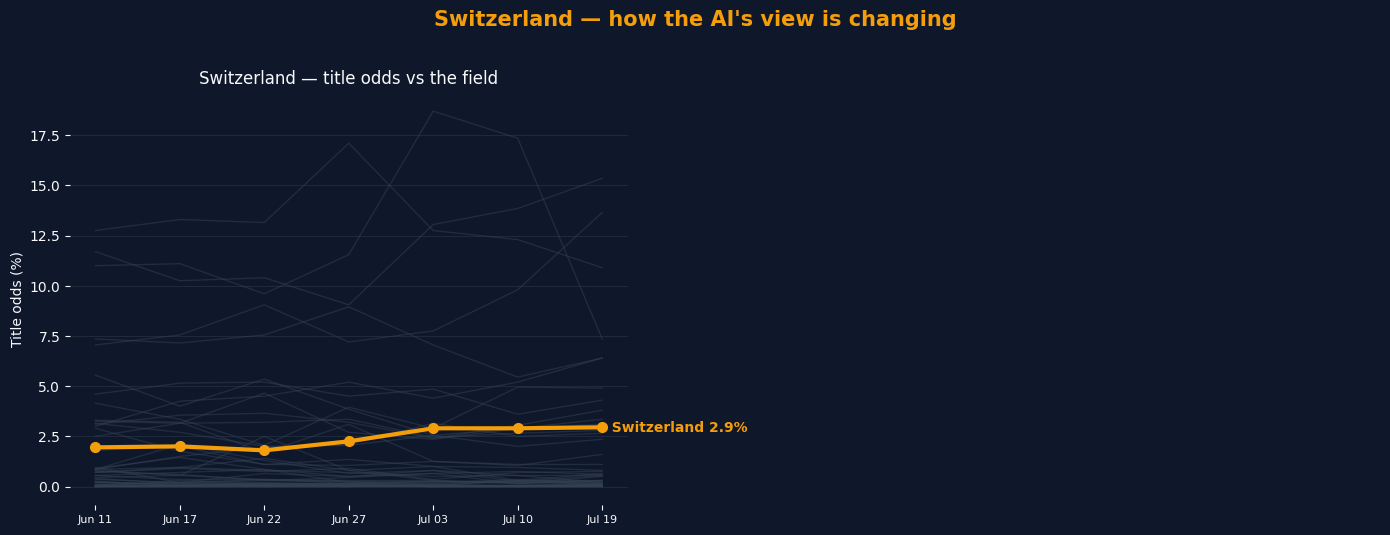


📈  Plotting trend for Colombia…
Saved → visuals/team_trend_colombia.png


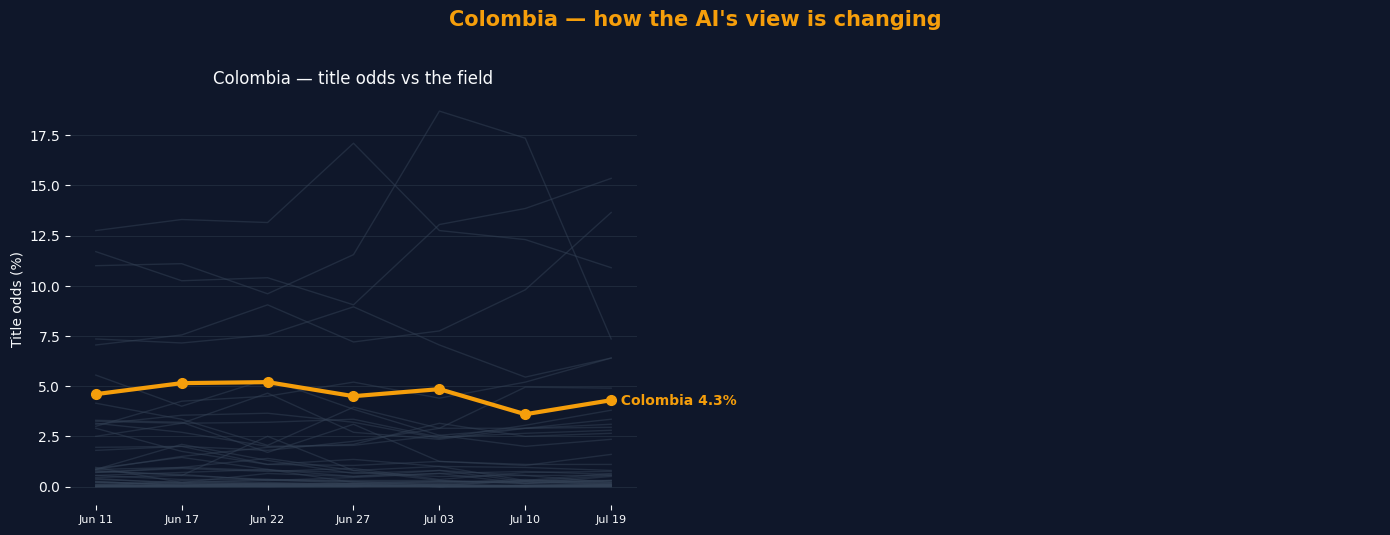


📈  Plotting trend for Morocco…
Saved → visuals/team_trend_morocco.png


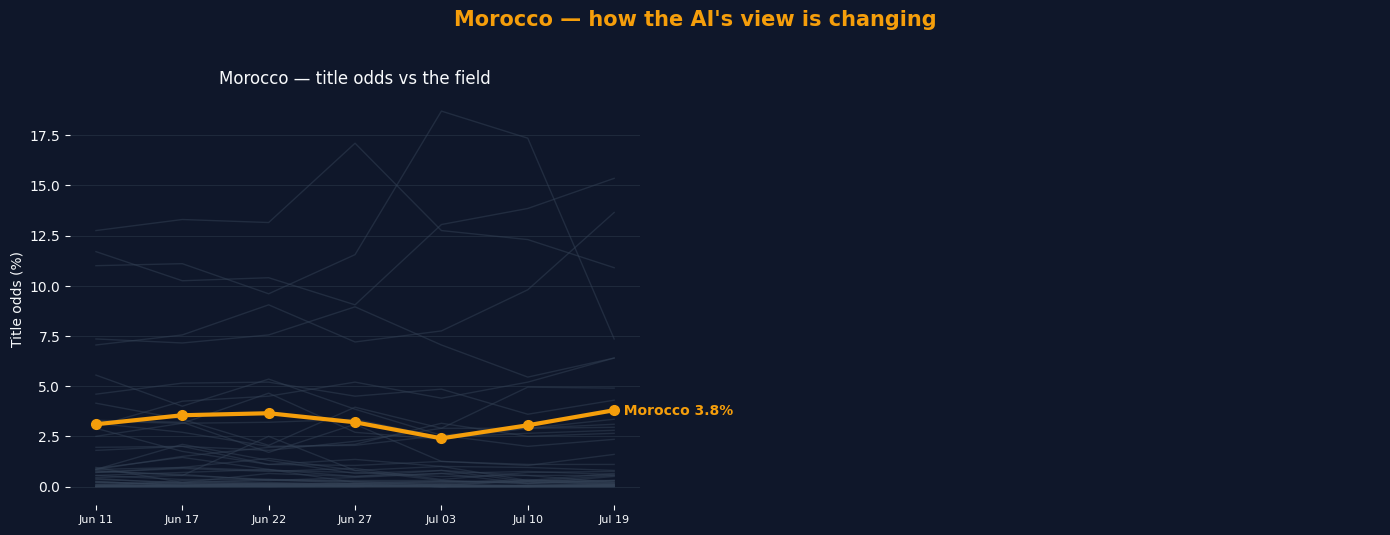


📈  Plotting trend for England…
Saved → visuals/team_trend_england.png


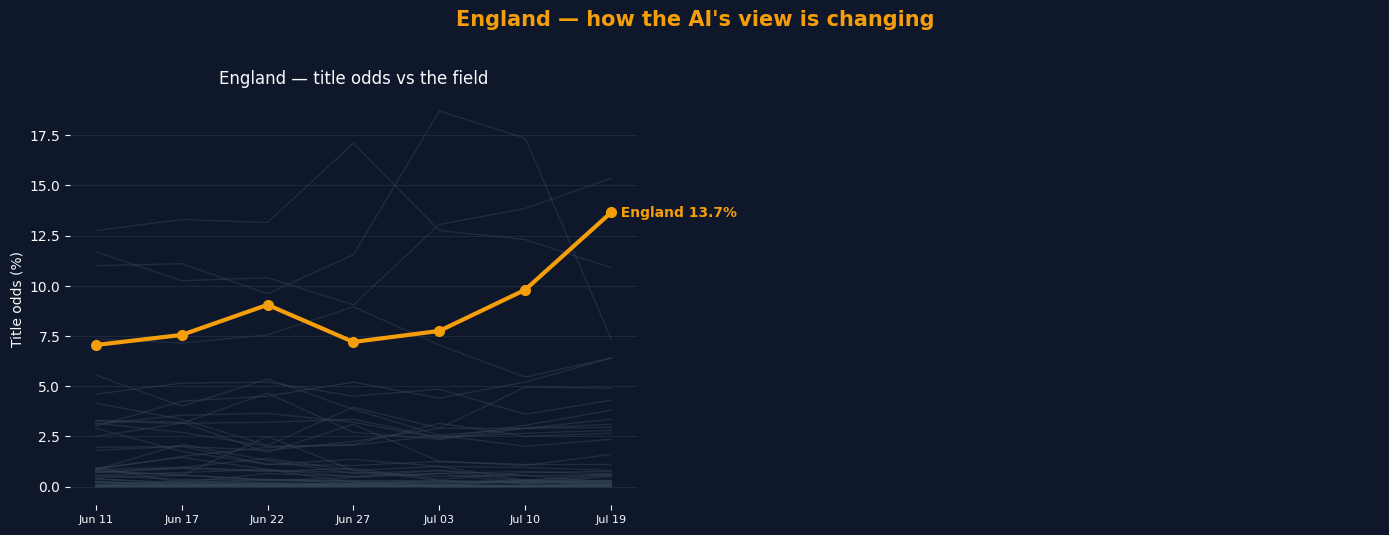

In [9]:
# ── Focus on a single team: title-odds trajectory + its next match ────────────
def team_trend(team, save_path=None):
    """Overlay a team's title-odds path on the field and show its next match."""
    save_path = save_path or f"visuals/team_trend_{team.lower().replace(' ', '_')}.png"
    th = champ_hist[champ_hist["team"] == team].sort_values("as_of")
    tf = fix_hist[(fix_hist["home"] == team) | (fix_hist["away"] == team)]
    x  = list(range(len(th)))

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(14, 5.2), facecolor=COLORS["bg"],
        gridspec_kw={"width_ratios": [1, 1.1]},
    )

    # ── Left: title odds, this team highlighted against the faded field ──
    ax1.set_facecolor(COLORS["bg"])
    for t in champ_hist["team"].unique():
        s = champ_hist[champ_hist["team"] == t].sort_values("as_of")
        ax1.plot(x, s["title_pct"], color="#334155", lw=1, alpha=0.5)
    ax1.plot(x, th["title_pct"], color=COLORS["accent"], lw=3, marker="o", ms=7)
    ax1.text(x[-1], th["title_pct"].iloc[-1],
             f"  {team} {th['title_pct'].iloc[-1]:.1f}%",
             color=COLORS["accent"], fontweight="bold", va="center", fontsize=10)
    ax1.set_xticks(x)
    ax1.set_xticklabels([d.strftime("%b %d") for d in th["as_of"]],
                        color=COLORS["text"], fontsize=8)
    ax1.set_ylabel("Title odds (%)", color=COLORS["text"])
    ax1.tick_params(colors=COLORS["text"])
    ax1.grid(axis="y", color="#1E293B", lw=0.8)
    for s in ax1.spines.values():
        s.set_visible(False)
    ax1.set_title(f"{team} — title odds vs the field", color=COLORS["text"], fontsize=12)

    # ── Right: prediction evolution for this team's next upcoming match ──
    ax2.set_facecolor(COLORS["bg"])
    if not tf.empty:
        nextm = tf.sort_values("date")["match"].iloc[0]
        g  = fix_hist[fix_hist["match"] == nextm].sort_values("as_of")
        xx = list(range(len(g)))
        home_is_team = g.iloc[0]["home"] == team
        win  = (g["p_home"] if home_is_team else g["p_away"]).to_numpy()
        lose = (g["p_away"] if home_is_team else g["p_home"]).to_numpy()
        opp  = g.iloc[0]["away"] if home_is_team else g.iloc[0]["home"]
        ax2.plot(xx, win * 100,           color=COLORS["home"], lw=2.6, marker="o", label=f"{team} win")
        ax2.plot(xx, g["p_draw"] * 100,   color=COLORS["draw"], lw=2.6, marker="o", label="Draw")
        ax2.plot(xx, lose * 100,          color=COLORS["away"], lw=2.6, marker="o", label=f"{opp} win")
        for xi in xx:
            ax2.text(xi, max(win[xi], lose[xi]) * 100 + 3, g.iloc[xi]["score"],
                     ha="center", color=COLORS["text"], fontsize=8, fontweight="bold")
        ax2.set_title(f"Next up: {team} vs {opp}  ({g.iloc[0]['date']})",
                      color=COLORS["text"], fontsize=12)
        ax2.set_xticks(xx)
        ax2.set_xticklabels([d.strftime("%b %d") for d in g["as_of"]],
                            color=COLORS["text"], fontsize=8)
        ax2.set_ylabel("Probability (%)", color=COLORS["text"])
        ax2.set_ylim(0, 100)
        ax2.tick_params(colors=COLORS["text"])
        ax2.grid(axis="y", color="#1E293B", lw=0.8)
        ax2.legend(facecolor=COLORS["bg"], labelcolor=COLORS["text"], framealpha=0, fontsize=9)
    else:
        ax2.axis("off")
    for s in ax2.spines.values():
        s.set_visible(False)

    fig.suptitle(f"{team} — how the AI's view is changing",
                 color=COLORS["accent"], fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    pathlib.Path(save_path).parent.mkdir(exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=COLORS["bg"])
    print(f"Saved → {save_path}")
    plt.show()
    plt.close(fig)


# Germany surged after their 7–1 opener — a clean example. Swap in any nation.
for t in ["USA", "Belgium", "Argentina", "France", "Norway", "Egypt", "Portugal", "Switzerland", "Colombia", "Morocco","England"]:
    print(f"\n📈  Plotting trend for {t}…")
    team_trend(t)

## 🗺️ Most-likely bracket — Round of 32 → Final

Projects the **single most-likely path** through the knockout stage. Group games
still to play are filled with the model's predicted scorelines, the 12 group
tables are ranked (incl. the eight best third-placed teams), and everyone is
slotted into the official FIFA 2026 bracket. At every tie the higher win
probability advances, all the way to a projected **champion**.

> The full bracket is data-driven — as real results land in openfootball, re-running
> this section redraws the projection. Saved to `visuals/bracket.png` +
> `visuals/bracket_predictions.csv`.

In [10]:
# ── Resolve the most-likely knockout bracket, Round of 32 → Final ─────────────
# Strategy: (1) project final group standings from real results + predicted
# scorelines for any games still to play; (2) rank the 12 third-placed teams and
# keep the best 8; (3) slot the eight qualifying thirds using FIFA's *official*
# Annexe C allocation table (not a guess) and drop the winners/runners-up into the
# bracket skeleton; (4) walk the tree, taking the higher win probability at each
# tie and propagating the winners to the Final.
import json
from collections import defaultdict
from predictor import _fetch_wc2026, normalize_team, HOST_NATIONS

# Official FIFA 2026 knockout skeleton — "1E"=group-E winner, "2C"=runner-up,
# "3:A/B/C/D/F"=a qualifying third from one of those groups, "W74"/"L101"=
# winner/loser of match 74 / 101.
BRACKET = {
    73: ("2A", "2B"), 74: ("1E", "3:A/B/C/D/F"), 75: ("1F", "2C"), 76: ("1C", "2F"),
    77: ("1I", "3:C/D/F/G/H"), 78: ("2E", "2I"), 79: ("1A", "3:C/E/F/H/I"),
    80: ("1L", "3:E/H/I/J/K"), 81: ("1D", "3:B/E/F/I/J"), 82: ("1G", "3:A/E/H/I/J"),
    83: ("2K", "2L"), 84: ("1H", "2J"), 85: ("1B", "3:E/F/G/I/J"), 86: ("1J", "2H"),
    87: ("1K", "3:D/E/I/J/L"), 88: ("2D", "2G"),
    89: ("W74", "W77"), 90: ("W73", "W75"), 91: ("W76", "W78"), 92: ("W79", "W80"),
    93: ("W83", "W84"), 94: ("W81", "W82"), 95: ("W86", "W88"), 96: ("W85", "W87"),
    97: ("W89", "W90"), 98: ("W93", "W94"), 99: ("W91", "W92"), 100: ("W95", "W96"),
    101: ("W97", "W98"), 102: ("W99", "W100"), 103: ("L101", "L102"), 104: ("W101", "W102"),
}
RND = {**{n: "Round of 32" for n in range(73, 89)},
       **{n: "Round of 16" for n in range(89, 97)},
       **{n: "Quarter-final" for n in range(97, 101)},
       101: "Semi-final", 102: "Semi-final", 103: "Third place", 104: "Final"}

# FIFA's official third-place allocation (Annexe C) — all 495 combinations of which
# groups' third-placed teams advance, each mapping a group-winner slot ("1E") to the
# group letter whose third it faces ("D"). Vendored from the verified
# dw-football/wc2026-bracket dataset.
THIRD_ALLOC = json.loads((pathlib.Path("data") / "third_place_allocation.json").read_text())

_neutral = lambda t: t not in HOST_NATIONS   # co-hosts play at home, everyone else neutral


def group_standings():
    """Project each group's final table — real scores where played, predicted otherwise."""
    feed = _fetch_wc2026()
    gm, members = defaultdict(list), defaultdict(set)
    for m in feed.get("matches", []):
        g = m.get("group")
        if not g:
            continue
        L = g.split()[-1]
        h, a = normalize_team(m.get("team1", "")), normalize_team(m.get("team2", ""))
        gm[L].append((h, a, (m.get("score") or {}).get("ft")))
        members[L].update([h, a])

    standings, thirds = {}, []
    for L in sorted(gm):
        tab = {t: dict(team=t, pts=0, gf=0, ga=0) for t in members[L]}
        for h, a, ft in gm[L]:
            if ft and len(ft) == 2:
                gh, ga = int(ft[0]), int(ft[1])
            else:
                p = predict_match(h, a, elo, model, feat_df, neutral=_neutral(h), is_wc=True)
                gh, ga = p["score_home"], p["score_away"]
            tab[h]["gf"] += gh; tab[h]["ga"] += ga
            tab[a]["gf"] += ga; tab[a]["ga"] += gh
            if gh > ga:   tab[h]["pts"] += 3
            elif gh < ga: tab[a]["pts"] += 3
            else:         tab[h]["pts"] += 1; tab[a]["pts"] += 1
        rows = list(tab.values())
        for r in rows:
            r["gd"], r["elo"], r["group"] = r["gf"] - r["ga"], elo.ratings[r["team"]], L
        rows.sort(key=lambda r: (r["pts"], r["gd"], r["gf"], r["elo"]), reverse=True)
        standings[L] = rows
        thirds.append(rows[2])
    thirds.sort(key=lambda r: (r["pts"], r["gd"], r["gf"], r["elo"]), reverse=True)
    return standings, thirds[:8]          # 8 best third-placed teams advance


def assign_thirds(qualified):
    """Map the 8 qualifying thirds onto the eight 3:-slots via FIFA's official table.

    The table is keyed by the sorted set of groups whose third-placed team advanced
    (e.g. "BDEFIJKL") and tells us which group's third each group-winner slot faces —
    so the assignment matches the real draw exactly, not just *a* legal pairing.
    """
    team_by_group = {q["group"]: q["team"] for q in qualified}
    key   = "".join(sorted(team_by_group))                 # e.g. "BDEFIJKL"
    alloc = THIRD_ALLOC.get(key)
    if alloc is None:
        raise KeyError(f"third-place combination {key} not in FIFA allocation table")
    return {n: team_by_group[alloc[host]]                  # alloc["1E"] == "D" → group-D third
            for n, (host, slot) in BRACKET.items() if str(slot).startswith("3:")}


def resolve_bracket():
    standings, qualified = group_standings()
    third = assign_thirds(qualified)
    winners, losers, recs = {}, {}, []
    for n in sorted(BRACKET):
        def slot(s, n=n):
            if s.startswith("W"):  return winners[int(s[1:])]
            if s.startswith("L"):  return losers[int(s[1:])]
            if s.startswith("3:"): return third[n]
            return standings[s[1]][int(s[0]) - 1]["team"]      # "1E" → group E, 1st
        t1, t2 = slot(BRACKET[n][0]), slot(BRACKET[n][1])
        p = predict_match(t1, t2, elo, model, feat_df, neutral=True, is_wc=True)
        w, l = (t1, t2) if p["p_home"] >= p["p_away"] else (t2, t1)
        winners[n], losers[n] = w, l
        recs.append({"num": n, "round": RND[n], "t1": t1, "t2": t2, "winner": w, "loser": l,
                     "score": f"{p['score_home']}–{p['score_away']}",
                     "conf": round(max(p["p_home"], p["p_away"]), 3)})
    return pd.DataFrame(recs), winners, standings


ko, winners, standings = resolve_bracket()

out_dir = pathlib.Path("visuals"); out_dir.mkdir(exist_ok=True)
ko.to_csv(out_dir / "bracket_predictions.csv", index=False)

champ, runner_up, third_place = winners[104], ko.loc[ko.num == 104, "loser"].iloc[0], winners[103]
for rnd in ["Round of 32", "Round of 16", "Quarter-final", "Semi-final", "Third place", "Final"]:
    print(f"\n— {rnd} —")
    for _, r in ko[ko["round"] == rnd].iterrows():
        print(f"  {r.t1:>22}  vs  {r.t2:<22}  →  {r.winner:<18} ({r.score}, {r.conf:.0%})")
print(f"\n🏆 Champion: {champ}    🥈 Runner-up: {runner_up}    🥉 Third: {third_place}")
print("Saved → visuals/bracket_predictions.csv")


— Round of 32 —
            South Africa  vs  Canada                  →  Canada             (0–2, 53%)
                 Germany  vs  Paraguay                →  Germany            (3–0, 50%)
             Netherlands  vs  Morocco                 →  Netherlands        (2–1, 38%)
                  Brazil  vs  Japan                   →  Brazil             (2–1, 45%)
                  France  vs  Sweden                  →  France             (4–0, 76%)
             Ivory Coast  vs  Norway                  →  Norway             (1–2, 62%)
                  Mexico  vs  Ecuador                 →  Mexico             (2–1, 44%)
                 England  vs  DR Congo                →  England            (6–0, 80%)
                     USA  vs  Bosnia and Herzegovina  →  USA                (3–0, 71%)
                 Belgium  vs  Senegal                 →  Belgium            (3–1, 48%)
                Portugal  vs  Croatia                 →  Portugal           (1–1, 49%)
                   Spain  

Saved → visuals/bracket.png


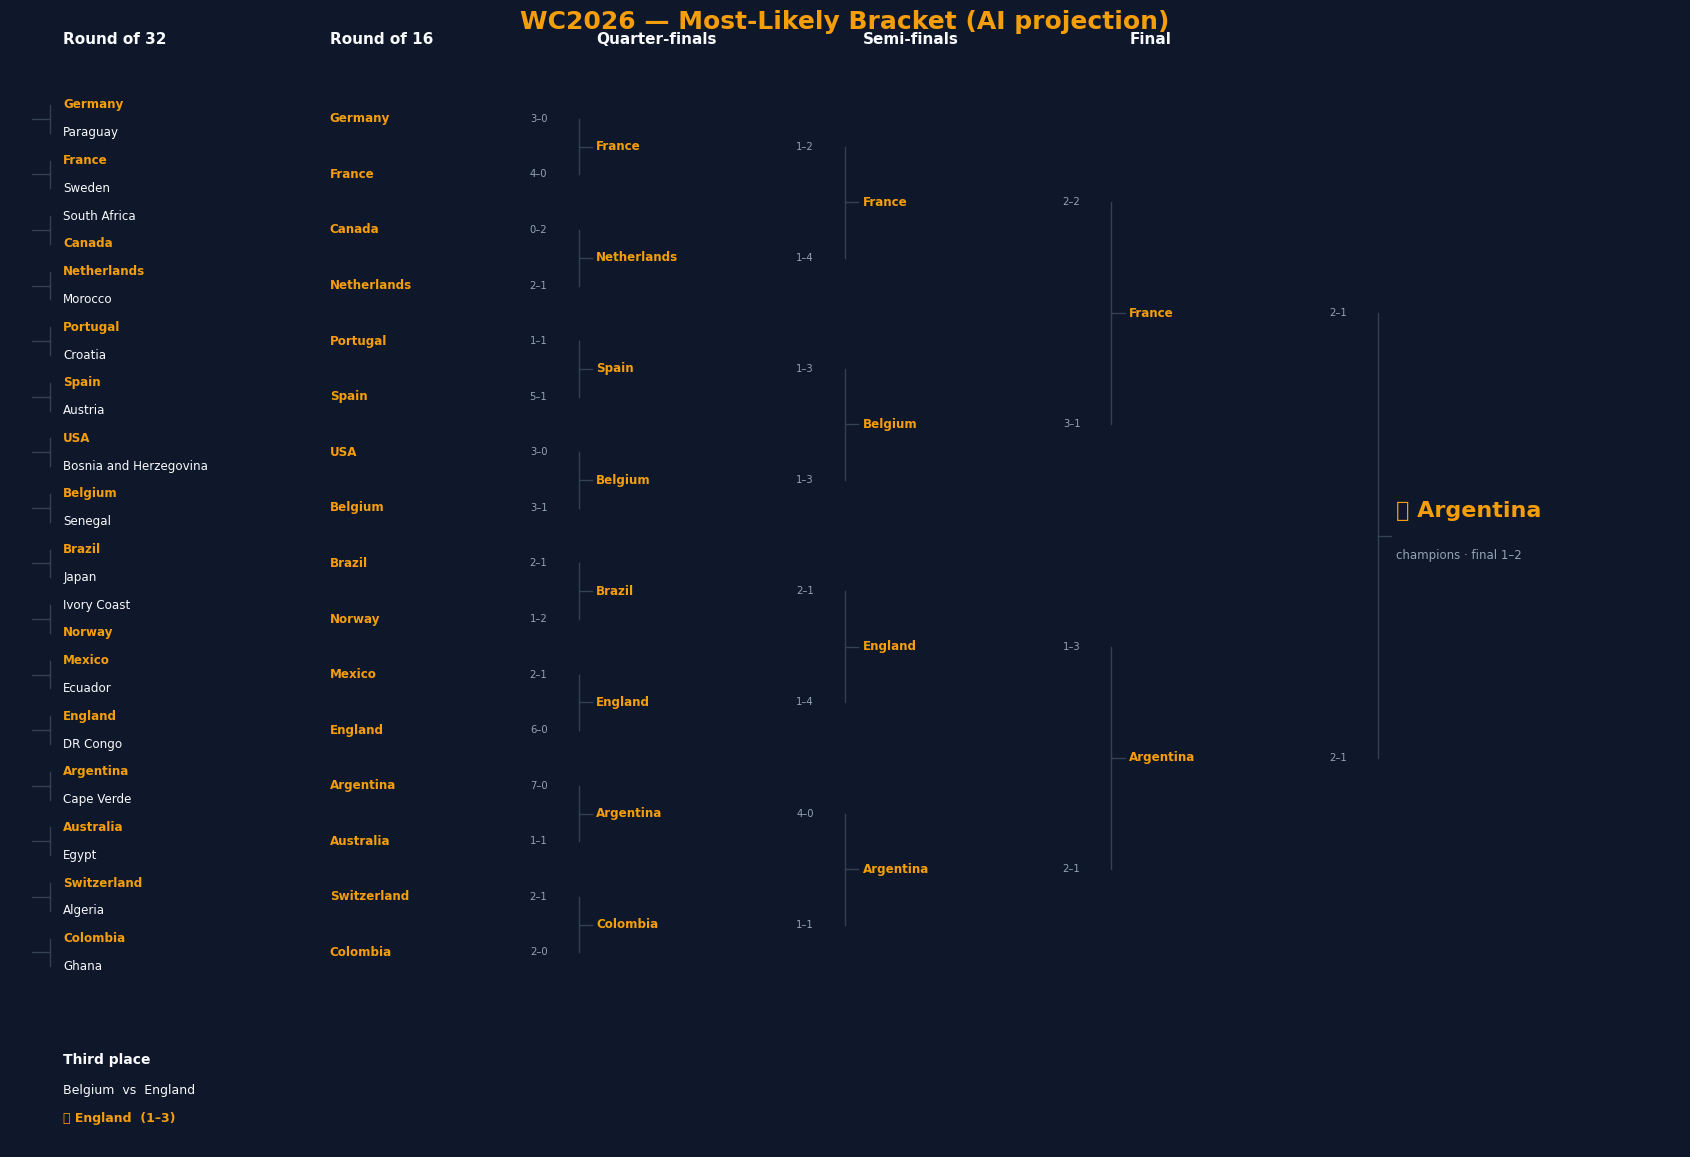

In [11]:
# ── Draw the projected bracket as a video-ready PNG ───────────────────────────
def _leaves(num):
    out = []
    for s in BRACKET[num]:
        if s.startswith("W"):
            out += _leaves(int(s[1:]))
    return out or [num]


def draw_bracket(ko, winners, save_path="visuals/bracket.png"):
    rec   = {r["num"]: r for _, r in ko.iterrows()}
    order = _leaves(104)                       # 16 R32 matches, top → bottom
    yc, inp = {}, {}
    for i, m in enumerate(order):
        top, bot = -(2 * i), -(2 * i + 1)
        yc[m]    = (top + bot) / 2
        inp[m]   = [(rec[m]["t1"], top), (rec[m]["t2"], bot)]
    for m in range(89, 105):
        if m == 103:
            continue
        kids = [int(s[1:]) for s in BRACKET[m] if s.startswith("W")]
        yc[m] = sum(yc[k] for k in kids) / len(kids)

    depth = {**{n: 0 for n in range(73, 89)}, **{n: 1 for n in range(89, 97)},
             **{n: 2 for n in range(97, 101)}, 101: 3, 102: 3, 104: 4}
    COLW = 3.0
    X = lambda c: c * COLW

    fig, ax = plt.subplots(figsize=(17, 12), facecolor=COLORS["bg"])
    ax.set_facecolor(COLORS["bg"]); ax.axis("off")

    def label(x, y, txt, win, score=None):
        ax.text(x, y, txt, color=(COLORS["accent"] if win else COLORS["text"]),
                fontsize=8.6, fontweight=("bold" if win else "normal"),
                va="center", ha="left")
        if score:
            ax.text(x + COLW - 0.55, y, score, color="#94A3B8",
                    fontsize=7.2, va="center", ha="right")

    # Round of 32 inputs (col 0) → winner (col 1)
    for m in order:
        (t1, y1), (t2, y2) = inp[m]
        for t, y in [(t1, y1), (t2, y2)]:
            label(X(0), y, t, t == winners[m])
        ax.plot([X(0) - 0.15, X(0) - 0.15], [y1, y2], color="#334155", lw=1)
        ax.plot([X(0) - 0.15, X(0) - 0.35], [yc[m], yc[m]], color="#334155", lw=1)

    # Winner of every later match at col = depth + 1, with feeder connectors
    for m in sorted(rec):
        if m in (103, 104):
            continue
        d = depth[m]
        label(X(d + 1), yc[m], rec[m]["winner"], True, rec[m]["score"])
        kids = [int(s[1:]) for s in BRACKET[m] if s.startswith("W")]
        if kids:
            ys = [yc[k] for k in kids]
            ax.plot([X(d) + COLW - 0.2, X(d) + COLW - 0.2], [min(ys), max(ys)],
                    color="#334155", lw=1)
            ax.plot([X(d) + COLW - 0.2, X(d + 1) - 0.05], [yc[m], yc[m]],
                    color="#334155", lw=1)

    # Final connector + champion crown
    fin  = rec[104]
    kids = [int(s[1:]) for s in BRACKET[104]]
    ys   = [yc[k] for k in kids]
    ax.plot([X(4) + COLW - 0.2, X(4) + COLW - 0.2], [min(ys), max(ys)], color="#334155", lw=1)
    ax.plot([X(4) + COLW - 0.2, X(5) - 0.05], [yc[104], yc[104]], color="#334155", lw=1)
    ax.text(X(5), yc[104] + 0.9, f"\U0001f3c6 {winners[104]}", color=COLORS["accent"],
            fontsize=16, fontweight="bold", va="center", ha="left")
    ax.text(X(5), yc[104] - 0.7, f"champions · final {fin['score']}", color="#94A3B8",
            fontsize=8.5, va="center", ha="left")

    # Round headers + third-place inset
    for c, name in [(0, "Round of 32"), (1, "Round of 16"), (2, "Quarter-finals"),
                    (3, "Semi-finals"), (4, "Final")]:
        ax.text(X(c), 2.2, name, color=COLORS["text"], fontsize=11, fontweight="bold", ha="left")
    tp = rec[103]
    ax.text(X(0), -34.5, "Third place", color=COLORS["text"], fontsize=10, fontweight="bold")
    ax.text(X(0), -35.6, f"{tp['t1']}  vs  {tp['t2']}", color=COLORS["text"], fontsize=9)
    ax.text(X(0), -36.6, f"\U0001f949 {tp['winner']}  ({tp['score']})",
            color=COLORS["accent"], fontsize=9, fontweight="bold")

    ax.set_xlim(-0.6, X(5) + 3.2); ax.set_ylim(-37.5, 3.2)
    fig.suptitle("WC2026 — Most-Likely Bracket (AI projection)", color=COLORS["accent"],
                 fontsize=18, fontweight="bold", y=0.96)
    plt.tight_layout()
    pathlib.Path(save_path).parent.mkdir(exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=COLORS["bg"])
    print(f"Saved → {save_path}")
    plt.show()


draw_bracket(ko, winners)